<a href="https://colab.research.google.com/github/ShorouqTelfah/Automated-methods-to-detect-pneumonia-diseases-from-medical-images/blob/main/TRAIN_CNN_VINDRMAMMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Step 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

# Step 2: Create destination folder in your Google Drive
import os

destination = "/content/drive/My Drive/vindr-mammo"
os.makedirs(destination, exist_ok=True)

Mounted at /content/drive


In [2]:
import pandas as pd

# Path to your saved CSV
csv_path = "/content/drive/MyDrive/vindr-mammo/train_image_level.csv"

# Load it
df = pd.read_csv(csv_path)

# Check shape (number of rows and columns)
print("Shape:", df.shape)

# Show first 5 rows
df.head()


Shape: (640, 32)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,...,Window Width,Rescale Intercept,Rescale Slope,Rescale Type,Window Center & Width Explanation,Manufacturer,Manufacturer's Model Name,Age Group,stratify_col,dicom_path
0,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,2f6e06d3d3d3b93694f040070ca064d0,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
1,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,65862aee30a500c012c5d5b551daa7af,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
2,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,1cf9fe6c6943d24ffc1977c172aed52a,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
3,620540eacf40713d457794075b6194ca,715d0cd24a42fde2813841a7e734f443,d87681a1005c500940e40dc27a4b2b5c,L,MLO,3518,2800,BI-RADS 2,DENSITY C,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY C,/content/drive/MyDrive/160image/physionet.org/...
4,99288599d73af38b70043141516a2e49,5f0c048ea425dc0ccb7b8666021ef700,bc9f441425e64b9982168d6f1d3e3bc5,R,MLO,3518,2800,BI-RADS 2,DENSITY D,training,...,1500,0,1,US,linear LUT,SIEMENS,Mammomat Inspiration,40-49,40-49_DENSITY D,/content/drive/MyDrive/160image/physionet.org/...


In [3]:
print(df.columns.tolist())

['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split', 'Series Instance UID', "Patient's Age", 'View Position', 'Image Laterality', 'Photometric Interpretation', 'Rows', 'Columns', 'Imager Pixel Spacing', 'Pixel Spacing', 'Pixel Padding Value', 'Pixel Padding Range Limit', 'Window Center', 'Window Width', 'Rescale Intercept', 'Rescale Slope', 'Rescale Type', 'Window Center & Width Explanation', 'Manufacturer', "Manufacturer's Model Name", 'Age Group', 'stratify_col', 'dicom_path']


In [4]:
df.sample(5)[["study_id", "image_id", "breast_birads", "dicom_path"]]

,study_id,image_id,breast_birads,dicom_path
286,cdb436d3f2a4c3e3c2d7798a9239ee59,e3dbfa164a9a19c3f28010263926e767,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
493,d4d36c652112fd0906b469af7f36e758,2b72bb5ef94edc9b407ff09c39cda8a0,BI-RADS 2,/content/drive/MyDrive/160image/physionet.org/...
57,90244ee9a41e4c05d1afd1582d248a75,6f4b261f5b22a3c0601973de802baf48,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
523,cceccf35004c6032e9755f843e374adc,10deef22b9a3691fb8a9431ef6aa60d4,BI-RADS 1,/content/drive/MyDrive/160image/physionet.org/...
215,825a572d61762a3ce212d135892a9f5a,e098d6dc3921db1200c97a13c1b89d78,BI-RADS 2,/content/drive/MyDrive/160image/physionet.org/...


In [5]:
import os

missing = df[~df["dicom_path"].apply(os.path.exists)]
print(f"Missing files: {len(missing)}")

if len(missing) > 0:
    print(missing["dicom_path"].head())
else:
    print("✅ All DICOM paths are valid!")

Missing files: 0
✅ All DICOM paths are valid!


In [6]:
!pip install pydicom


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.7 MB/s eta 0:00:00


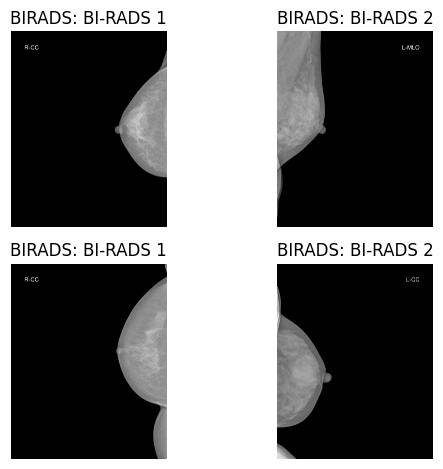

In [7]:
import matplotlib.pyplot as plt
import pydicom
import random

for i in range(4):
    idx = random.randint(0, len(df)-1)
    path = df.iloc[idx]["dicom_path"]
    birads = df.iloc[idx]["breast_birads"]
    ds = pydicom.dcmread(path)
    plt.subplot(2, 2, i+1)
    plt.imshow(ds.pixel_array, cmap='gray')
    plt.title(f"BIRADS: {birads}")
    plt.axis('off')

plt.tight_layout()
plt.show()